In [3]:
import pandas as pd
import numpy as np

In [12]:

def calculate_topsis(matrix, weights, impacts):
    norm_matrix = matrix / np.sqrt((matrix**2).sum())
    weighted_matrix = norm_matrix * weights
    v_plus = []
    v_minus = []

    for i, impact in enumerate(impacts):
        column = weighted_matrix.iloc[:, i]
        if impact == '+':
            v_plus.append(column.max())
            v_minus.append(column.min())
        else:
            v_plus.append(column.min())
            v_minus.append(column.max())

    s_plus = np.sqrt(((weighted_matrix - v_plus)**2).sum(axis=1))
    s_minus = np.sqrt(((weighted_matrix - v_minus)**2).sum(axis=1))
    performance_score = s_minus / (s_plus + s_minus)

    return performance_score

In [13]:
data = {
    'Model': [
        'all-mpnet-base-v2',
        'all-distilroberta-v1',
        'all-MiniLM-L12-v2',
        'all-MiniLM-L6-v2',
        'paraphrase-albert-small-v2'
    ],
    'Accuracy_STS': [63.30, 59.80, 59.76, 58.80, 50.50],
    'Speed_Sent_Sec': [2800, 4000, 7500, 14200, 5000],
    'Size_MB': [420, 290, 120, 80, 43],
    'Dimensions': [768, 768, 384, 384, 768]
}

df = pd.DataFrame(data).set_index('Model')

In [14]:
weights = [0.4, 0.3, 0.2, 0.1]
impacts = ['+', '+', '-', '-']

df['TOPSIS_Score'] = calculate_topsis(df, weights, impacts)
df['Rank'] = df['TOPSIS_Score'].rank(ascending=False).astype(int)
print("--- Final Model Ranking ---")
print(df.sort_values(by='Rank'))

--- Final Model Ranking ---
                            Accuracy_STS  Speed_Sent_Sec  Size_MB  Dimensions  \
Model                                                                           
all-MiniLM-L6-v2                   58.80           14200       80         384   
all-MiniLM-L12-v2                  59.76            7500      120         384   
paraphrase-albert-small-v2         50.50            5000       43         768   
all-distilroberta-v1               59.80            4000      290         768   
all-mpnet-base-v2                  63.30            2800      420         768   

                            TOPSIS_Score  Rank  
Model                                           
all-MiniLM-L6-v2                0.923578     1  
all-MiniLM-L12-v2               0.547677     2  
paraphrase-albert-small-v2      0.471196     3  
all-distilroberta-v1            0.231228     4  
all-mpnet-base-v2               0.138677     5  


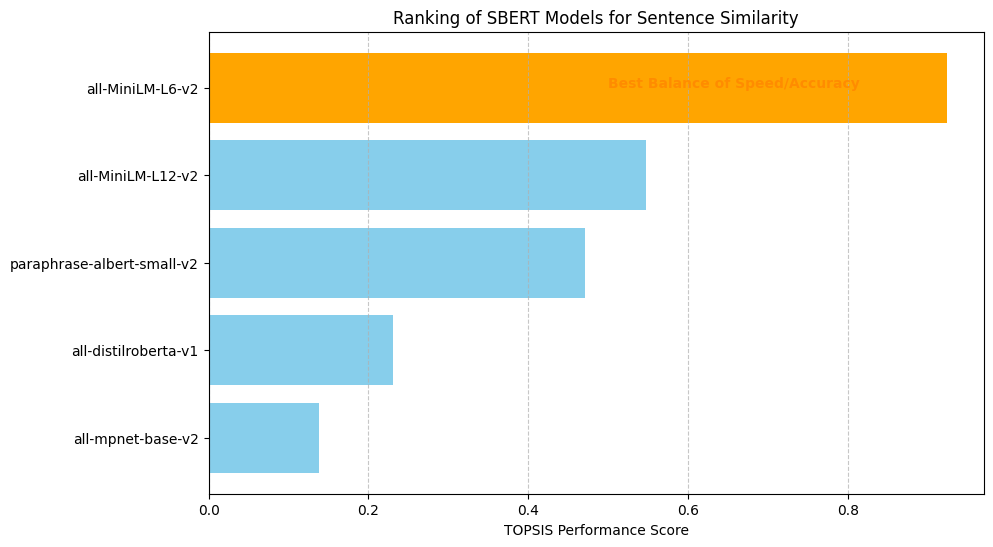

In [15]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
df_sorted = df.sort_values(by='TOPSIS_Score', ascending=True)
colors = ['skyblue' if x < df_sorted['TOPSIS_Score'].max() else 'orange' for x in df_sorted['TOPSIS_Score']]

plt.barh(df_sorted.index, df_sorted['TOPSIS_Score'], color=colors)
plt.xlabel('TOPSIS Performance Score')
plt.title('Ranking of SBERT Models for Sentence Similarity')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.text(0.5, 4, "Best Balance of Speed/Accuracy", color='darkorange', fontweight='bold')
plt.show()